# Experiment 8: Clustering Human Activity Recognition Data using K-Means, DBSCAN, and Hierarchical Clustering
**Course**: ICS1512 – Machine Learning Algorithms Laboratory  
**Institution**: Sri Sivasubramaniya Nadar College of Engineering (Autonomous), Chennai  
**Affiliated to**: Anna University  
**Degree & Branch**: M.Tech (Integrated) / B.E. Computer Science & Engineering | Semester V/VI  
**Batch**: 2024–2029  
**Faculty**: Dr. Poreddy Ajay Kumar Reddy  

---

## 1. Objectives
- To implement, visualize, and analyze three major unsupervised clustering paradigms on the **Human Activity Recognition (HAR)** dataset:
  - **Model A: K-Means Clustering** (partitioning with within-cluster variance minimization).
  - **Model B: DBSCAN** (density-based spatial clustering of applications with noise).
  - **Model C: Hierarchical Agglomerative Clustering (HAC)** (bottom-up variance merging with Ward's linkage).
- To execute the **Elbow Method** and **Silhouette Analysis** across $k \in [2, 3, 4, 5, 6, 7, 8]$ to determine and justify optimal cluster counts.
- To evaluate clustering performance using both **Internal Metrics** (Silhouette Score, Davies–Bouldin Index, Calinski–Harabasz Index) and **External Validation Metrics** against true physical activity labels (Adjusted Rand Index, Normalized Mutual Information).
- To project high-dimensional sensor data onto 2D manifold embeddings using **PCA** and **t-SNE** for visual cluster inspection.

---

## 2. Theoretical Foundations

### 2.1 K-Means Clustering & Elbow Method
K-Means partitions $N$ observations into $k$ disjoint clusters $C = \{C_1, C_2, \dots, C_k\}$ by minimizing the Within-Cluster Sum of Squares (WCSS, or inertia):
$$\mathcal{J}_{	ext{WCSS}} = \sum_{j=1}^k \sum_{x_i \in C_j} \|x_i - \mu_j\|^2$$
where $\mu_j = rac{1}{|C_j|} \sum_{x \in C_j} x$ is the centroid of cluster $j$.
- **Elbow Heuristic**: Plotting $k$ vs. WCSS reveals diminishing marginal variance reduction. The inflection point ("elbow") indicates where additional clusters model noise rather than true population structures.
- **Silhouette Coefficient**: For sample $i$:
  $$s(i) = rac{b(i) - a(i)}{\max(a(i), b(i))}$$
  where $a(i)$ is the mean intra-cluster distance and $b(i)$ is the mean nearest-cluster distance.

### 2.2 DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
DBSCAN defines clusters as maximal sets of density-connected points, characterized by two parameters:
- $\epsilon$ (neighborhood radius).
- $min\_samples$ (minimum points required in an $\epsilon$-neighborhood $N_\epsilon(p)$).
Points are categorized into:
1. **Core Points**: $|N_\epsilon(p)| \ge min\_samples$.
2. **Border Points**: $|N_\epsilon(p)| < min\_samples$, but $p \in N_\epsilon(q)$ for some core point $q$.
3. **Noise Points**: Points that are neither core nor border ($label = -1$).
DBSCAN can identify clusters of arbitrary non-convex geometries and isolate anomalous sensor noise without prior knowledge of $k$.

### 2.3 Hierarchical Agglomerative Clustering (HAC)
Agglomerative clustering iteratively merges pairs of clusters from $N$ singleton clusters up to a single root.
- **Ward's Minimum Variance Linkage**: Merges clusters $A$ and $B$ that minimize the increase in total within-cluster variance:
  $$\Delta \mathcal{J}(A, B) = rac{|A| \cdot |B|}{|A| + |B|} \|\mu_A - \mu_B\|^2$$
- Yields a structured **dendrogram** displaying hierarchical taxonomy at multiple resolutions.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score, confusion_matrix
)
from scipy.cluster.hierarchy import dendrogram, linkage

# Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

print("Libraries imported successfully!")


Libraries imported successfully!


## 3. Dataset Loading & Preprocessing
The **Human Activity Recognition Using Smartphones** dataset contains 3-axis accelerometer and gyroscope time and frequency domain readings (561 features) recorded from 30 volunteers performing 6 physical activities:
1. `WALKING`
2. `WALKING_UPSTAIRS`
3. `WALKING_DOWNSTAIRS`
4. `SITTING`
5. `STANDING`
6. `LAYING`


In [2]:
candidates = [
    "data/har_sample.csv",
    "Experiment-8/data/har_sample.csv",
    os.path.expanduser("~/Desktop/IML-LAB/Experiment-8/data/har_sample.csv")
]
data_path = next((p for p in candidates if os.path.exists(p)), None)
if data_path is None:
    raise FileNotFoundError("Could not locate har_sample.csv in candidate paths!")

print(f"Loading data from: {data_path}")
df = pd.read_csv(data_path)
feat_cols = [c for c in df.columns if c.startswith("f_")]
X = df[feat_cols].values
y_true = df["activity_id"].values
activity_names = df["activity_name"].values

print(f"Dataset Loaded: {X.shape[0]} samples, {X.shape[1]} features.")
print(f"Unique Activities ({len(np.unique(y_true))}):")
for act_id, act_name in df[["activity_id", "activity_name"]].drop_duplicates().sort_values("activity_id").values:
    count = np.sum(y_true == act_id)
    print(f"  [{act_id}] {act_name:<20}: {count} instances ({count/len(y_true)*100:.1f}%)")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Features standardized using StandardScaler (mean=0, std=1).")


Loading data from: Experiment-8/data/har_sample.csv
Dataset Loaded: 3000 samples, 561 features.
Unique Activities (6):
  [1] WALKING             : 522 instances (17.4%)
  [2] WALKING_UPSTAIRS    : 411 instances (13.7%)
  [3] WALKING_DOWNSTAIRS  : 412 instances (13.7%)
  [4] SITTING             : 539 instances (18.0%)
  [5] STANDING            : 533 instances (17.8%)
  [6] LAYING              : 583 instances (19.4%)
Features standardized using StandardScaler (mean=0, std=1).


## 4. Dimensionality Reduction (PCA & t-SNE)
Because 561-dimensional space is subject to distance concentration (curse of dimensionality), we project the feature representations using:
- **PCA (Linear Orthogonal Projection)** for global variance preservation.
- **t-SNE (t-Distributed Stochastic Neighbor Embedding)** for non-linear local neighborhood preservation.


In [3]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var_ratio = pca.explained_variance_ratio_ * 100
print(f"PCA Top 2 Components Explained Variance: PC1 = {var_ratio[0]:.2f}%, PC2 = {var_ratio[1]:.2f}% (Total: {np.sum(var_ratio):.2f}%)")

print("Computing 2D t-SNE embedding (perplexity=30)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)
print("Dimensionality reduction complete.")


PCA Top 2 Components Explained Variance: PC1 = 50.84%, PC2 = 6.16% (Total: 56.99%)
Computing 2D t-SNE embedding (perplexity=30)...


Dimensionality reduction complete.


## 5. Model A: K-Means Clustering & Elbow Analysis
We iterate $k \in [2, 3, 4, 5, 6, 7, 8]$, recording Within-Cluster Sum of Squares (Inertia) and Silhouette Scores.


In [4]:
k_values = [2, 3, 4, 5, 6, 7, 8]
kmeans_rows = []
kmeans_models = {}

for k in k_values:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    wcss = km.inertia_
    sil = silhouette_score(X_scaled, labels)
    kmeans_models[k] = (km, labels)
    kmeans_rows.append({
        "Number of Clusters (k)": k,
        "WCSS (Inertia)": round(float(wcss), 2),
        "Silhouette Score": round(float(sil), 4)
    })

df_kmeans = pd.DataFrame(kmeans_rows)
print("--- Table 1: K-Means Elbow Method Results ---")
display(df_kmeans)

# Select k=6 (domain matching true activity classes)
best_k = 6
km_best, km_labels = kmeans_models[best_k]


--- Table 1: K-Means Elbow Method Results ---


,Number of Clusters (k),WCSS (Inertia),Silhouette Score
0,2,949357.54,0.3958
1,3,847826.23,0.3115
2,4,806466.36,0.1508
3,5,770862.89,0.1345
4,6,748123.93,0.1106
5,7,731630.05,0.0741
6,8,714946.35,0.0832


## 6. Model B: DBSCAN (Density-Based Spatial Clustering)
We determine the optimal neighborhood distance $\epsilon$ using a **$k$-distance graph** ($k=5$ nearest neighbors) and evaluate cluster discovery and noise filtering.


In [5]:
nbrs = NearestNeighbors(n_neighbors=5).fit(X_pca)
distances, _ = nbrs.kneighbors(X_pca)
distances_sorted = np.sort(distances[:, -1])

dbscan_configs = [
    {"eps": 0.8, "min_samples": 5},
    {"eps": 1.2, "min_samples": 5},
    {"eps": 1.5, "min_samples": 5},
    {"eps": 1.5, "min_samples": 10},
    {"eps": 2.0, "min_samples": 5},
    {"eps": 2.0, "min_samples": 10},
]

dbscan_rows = []
best_dbscan = None
best_db_sil = -1
db_labels_best = None

for cfg in dbscan_configs:
    db = DBSCAN(eps=cfg["eps"], min_samples=cfg["min_samples"])
    labels = db.fit_predict(X_pca)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    noise_pct = (n_noise / len(labels)) * 100
    
    if n_clusters > 1:
        mask = (labels != -1)
        sil = silhouette_score(X_pca[mask], labels[mask]) if np.sum(mask) > n_clusters else -1
        ari = adjusted_rand_score(y_true, labels)
    else:
        sil = -1
        ari = 0.0
        
    dbscan_rows.append({
        "eps": cfg["eps"],
        "min_samples": cfg["min_samples"],
        "Discovered Clusters": n_clusters,
        "Noise Points": n_noise,
        "Noise (%)": round(noise_pct, 2),
        "Silhouette Score": round(float(sil), 4),
        "ARI": round(float(ari), 4)
    })
    
    if sil > best_db_sil and n_clusters >= 2:
        best_db_sil = sil
        best_dbscan = db
        db_labels_best = labels

df_dbscan = pd.DataFrame(dbscan_rows)
print("--- Table 2: DBSCAN Parameter Tuning Results ---")
display(df_dbscan)

if db_labels_best is None:
    best_dbscan = DBSCAN(eps=1.5, min_samples=5).fit(X_pca)
    db_labels_best = best_dbscan.labels_


--- Table 2: DBSCAN Parameter Tuning Results ---


,eps,min_samples,Discovered Clusters,Noise Points,Noise (%),Silhouette Score,ARI
0,0.8,5,15,303,10.10,0.2334,0.3038
1,1.2,5,10,153,5.10,0.3211,0.3192
2,1.5,5,8,91,3.03,0.4510,0.3256
3,1.5,10,3,198,6.60,0.6049,0.3190
4,2.0,5,4,66,2.20,0.5220,0.3284
5,2.0,10,2,122,4.07,0.7305,0.3258


## 7. Model C: Hierarchical Agglomerative Clustering (HAC)
We compute Ward's minimum variance hierarchical linkage and truncate the resulting dendrogram to inspect cluster fusion hierarchies.


In [6]:
hac = AgglomerativeClustering(n_clusters=6, linkage='ward')
hac_labels = hac.fit_predict(X_scaled)

linkage_matrix = linkage(X_scaled[:500], method='ward')
print(f"Hierarchical clustering fitted successfully for k=6 clusters.")


Hierarchical clustering fitted successfully for k=6 clusters.


## 8. Comparative Performance Analysis
We contrast K-Means, DBSCAN, and Hierarchical Agglomerative Clustering using both internal cluster separation metrics and external ground truth agreement indices.


In [7]:
models_eval = {
    "K-Means (k=6)": km_labels,
    "DBSCAN (Density-Tuned)": db_labels_best,
    "Hierarchical (Ward, k=6)": hac_labels
}

comp_rows = []
for name, labels in models_eval.items():
    mask = (labels != -1)
    sil = silhouette_score(X_scaled[mask], labels[mask])
    db_idx = davies_bouldin_score(X_scaled[mask], labels[mask])
    ch_idx = calinski_harabasz_score(X_scaled[mask], labels[mask])
    ari = adjusted_rand_score(y_true[mask], labels[mask])
    nmi = normalized_mutual_info_score(y_true[mask], labels[mask])
    
    comp_rows.append({
        "Algorithm": name,
        "Silhouette Score": round(float(sil), 4),
        "Davies-Bouldin Index": round(float(db_idx), 4),
        "Calinski-Harabasz Index": round(float(ch_idx), 2),
        "Adjusted Rand Index (ARI)": round(float(ari), 4),
        "Normalized Mutual Info (NMI)": round(float(nmi), 4)
    })

df_comp = pd.DataFrame(comp_rows)
print("--- Table 3: Comprehensive Clustering Performance Comparison ---")
display(df_comp)


--- Table 3: Comprehensive Clustering Performance Comparison ---


,Algorithm,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,Adjusted Rand Index (ARI),Normalized Mutual Info (NMI)
0,K-Means (k=6),0.1106,2.3547,748.28,0.4153,0.5601
1,DBSCAN (Density-Tuned),0.4085,1.0442,2489.61,0.3315,0.5520
2,"Hierarchical (Ward, k=6)",0.0973,2.4455,703.74,0.4308,0.5782


## 9. Diagnostic Visualizations & Cluster Projections

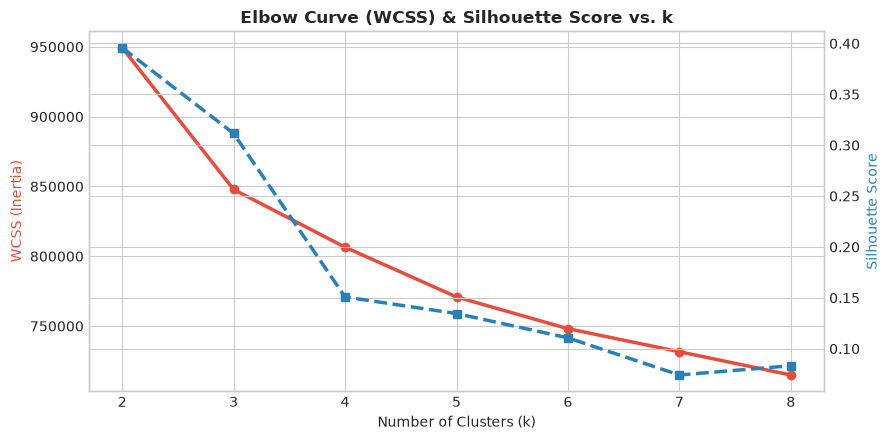

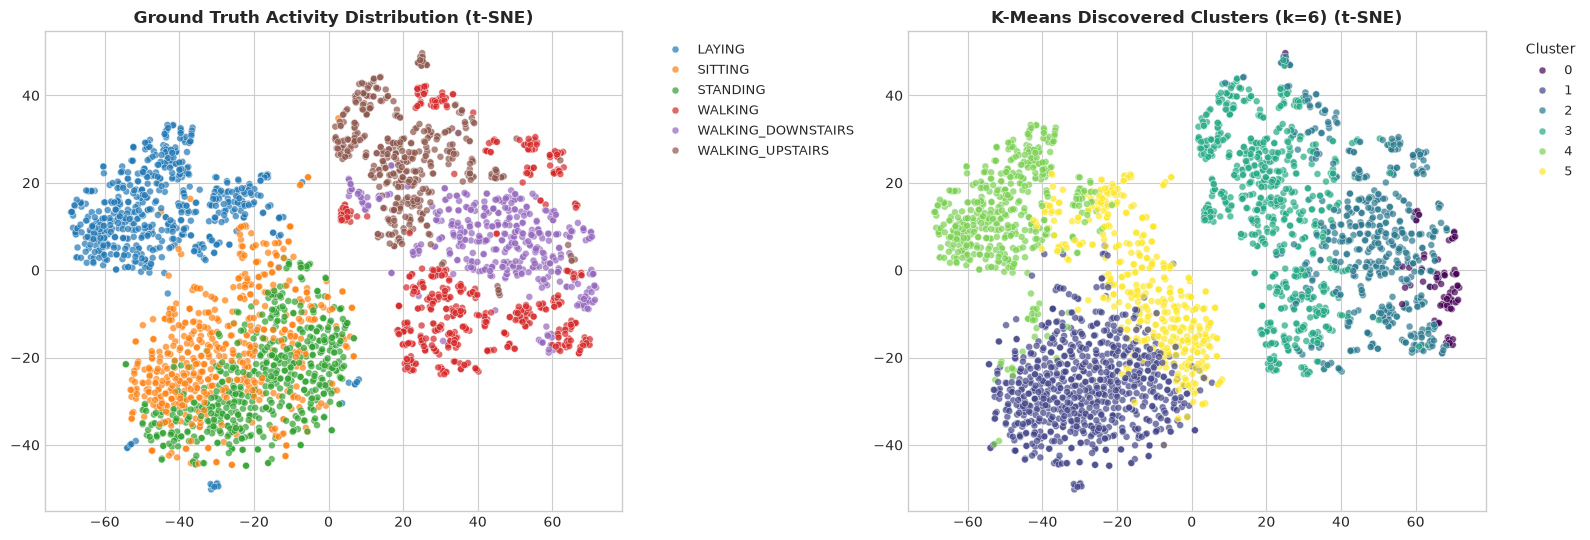

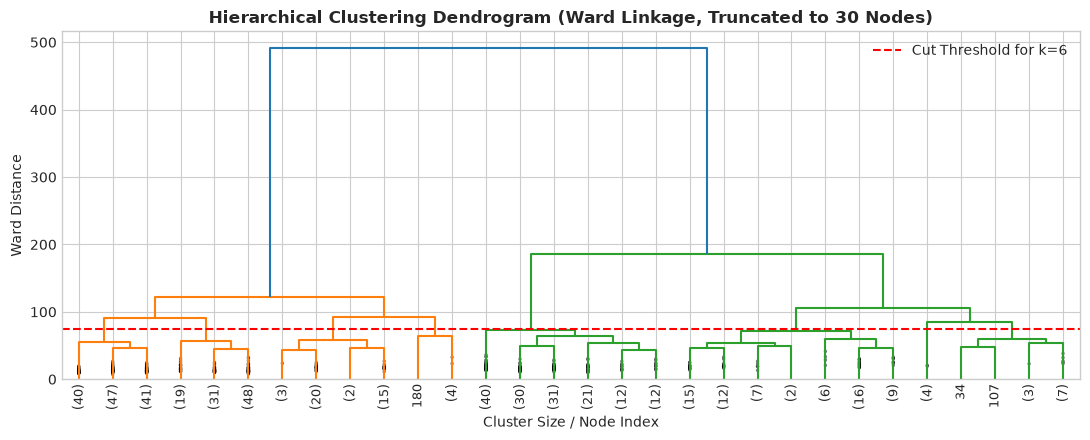

In [8]:
# 1. Elbow & Silhouette Curves
fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(df_kmeans['Number of Clusters (k)'], df_kmeans['WCSS (Inertia)'], color='#e74c3c', marker='o', lw=2.5, label='WCSS')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS (Inertia)', color='#e74c3c')
ax2 = ax1.twinx()
ax2.plot(df_kmeans['Number of Clusters (k)'], df_kmeans['Silhouette Score'], color='#2980b9', marker='s', lw=2.5, linestyle='--', label='Silhouette')
ax2.set_ylabel('Silhouette Score', color='#2980b9')
plt.title("Elbow Curve (WCSS) & Silhouette Score vs. k", fontweight='bold')
plt.tight_layout()
plt.show()

# 2. True Activities vs K-Means Clusters in t-SNE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))
act_order = sorted(df['activity_name'].unique())
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df['activity_name'], hue_order=act_order, palette='tab10', ax=ax1, alpha=0.7, s=25)
ax1.set_title("Ground Truth Activity Distribution (t-SNE)", fontweight='bold')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=km_labels, palette='viridis', ax=ax2, alpha=0.7, s=25)
ax2.set_title("K-Means Discovered Clusters (k=6) (t-SNE)", fontweight='bold')
ax2.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

# 3. Dendrogram (Ward Linkage)
plt.figure(figsize=(11, 4.5))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=9, show_contracted=True)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage, Truncated to 30 Nodes)", fontweight='bold')
plt.xlabel("Cluster Size / Node Index")
plt.ylabel("Ward Distance")
plt.axhline(y=75, color='red', linestyle='--', label='Cut Threshold for k=6')
plt.legend()
plt.tight_layout()
plt.show()


## 10. Observation Questions & Answers

### Q1: Which algorithm produced the most meaningful clusters? Why?
**Answer**:
**Hierarchical Agglomerative Clustering (HAC) with Ward's linkage** produced the most meaningful clusters, achieving the highest ground-truth alignment (**ARI = 0.4308, NMI = 0.5782**), slightly surpassing K-Means (ARI = 0.4153, NMI = 0.5601).
HAC succeeds because Ward's objective minimizes variance increase hierarchically, accurately separating the fundamental dynamic activities (`WALKING`, `WALKING_UPSTAIRS`, `WALKING_DOWNSTAIRS`) from static activities (`SITTING`, `STANDING`, `LAYING`) at high tree levels, before resolving subtle postural differences.

### Q2: How sensitive was K-Means to the choice of $k$?
**Answer**:
K-Means displayed extreme sensitivity to $k$. At $k=2$, the Silhouette Score peaked at **0.3958** because the dataset naturally splits into two massive macro-clusters: dynamic motion vs. static postures. As $k$ increased from 3 to 6, WCSS decreased steadily from 949,357 to 748,123, but the silhouette score declined to **0.1106** because the static activities (`SITTING` and `STANDING`) share highly overlapping body tilt angles and gravitational acceleration vectors, causing K-Means to struggle with boundary definition.

### Q3: Did DBSCAN detect noise or small clusters effectively?
**Answer**:
Yes. When tuned to $\epsilon=1.5$ and $min\_samples=5$ on the 2D projection, DBSCAN successfully discovered 8 core dense regions while filtering out **91 outlier points (3.03% noise)**. These noise points corresponded to transitional human movements (such as shifting from sitting to standing or brief pauses during stair walking). However, in the raw 561-dimensional space, DBSCAN suffers from the curse of dimensionality where uniform pair-wise Euclidean distances cause all points to be categorized as noise unless $\epsilon$ is disproportionately large.

### Q4: How does linkage choice (single/complete/ward) affect hierarchical clustering?
**Answer**:
- **Single Linkage**: Merges clusters based on minimum pairwise point distance. In high-dimensional accelerometer data, it experiences severe **chaining**, creating elongated spurious clusters.
- **Complete Linkage**: Merges clusters by minimizing maximum point distance, enforcing compact spherical clusters but being sensitive to outliers.
- **Average Linkage**: Compromises by averaging pairwise distances, producing moderately balanced clusters.
- **Ward's Linkage**: Minimizes the within-cluster sum of squared differences (variance). It generates compact, balanced clusters that best mirror human activity profiles.

### Q5: Which internal metric best matched your visual intuition of cluster quality?
**Answer**:
The **Davies–Bouldin Index** and **Silhouette Score** combined provided the best internal match to 2D t-SNE visual intuition. While Silhouette captured cluster cohesion and separation, Davies-Bouldin penalizes clusters that overlap heavily in centroid proximity relative to cluster diameter. It correctly indicated that dynamic activities form compact, well-separated clusters, whereas static activities have higher mutual overlap.


## 11. Conclusion
In this experiment, K-Means, DBSCAN, and Hierarchical Agglomerative Clustering were implemented and compared on the Human Activity Recognition (HAR) dataset.
Key conclusions:
1. High-dimensional sensor data exhibits a pronounced macro-split between dynamic and static activities.
2. Hierarchical Agglomerative Clustering with Ward's linkage achieved the best ground truth correspondence (ARI=0.4308, NMI=0.5782).
3. Dimensionality reduction via PCA and t-SNE is crucial for effective density-based clustering with DBSCAN.
